# Fashion-MNIST Classification Project

## Introduction

In this notebook, we study a supervised **multi-class classification** problem
using the **Fashion-MNIST** dataset.  
The objective is to automatically classify grayscale images of clothing items
into one of **10 categories**.

We will follow the standard classification workflow presented in the
course (Chapter: Classification), including:
- Data loading
- Data exploration
- Preprocessing
- Model training
- Evaluation and analysis


# MNIST

### Dataset Description

Fashion-MNIST is a dataset of grayscale images representing fashion products.
Each image has a size of **28 × 28 pixels** and belongs to one of the following
10 classes:

| Label | Class        |
|------:|-------------|
| 0     | T-shirt/top |
| 1     | Trouser     |
| 2     | Pullover    |
| 3     | Dress       |
| 4     | Coat        |
| 5     | Sandal     |
| 6     | Shirt      |
| 7     | Sneaker    |
| 8     | Bag        |
| 9     | Ankle boot |

The dataset is divided into:
- 60,000 training images
- 10,000 test images


In [ ]:
import os
import urllib.request
import gzip
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score

from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPooling2D, Flatten,
    Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras


## Load Data

In [ ]:
def generateData():
        fashion_mnist = keras.datasets.fashion_mnist
        (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

        print("Train Samples:", len(X_train))
        print("Test Samples:",  len(X_test))

        return (X_train, y_train), (X_test, y_test)
(X_train, y_train), (X_test, y_test) = generateData()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train Samples: 60000
Test Samples: 10000


In [ ]:

#Class mappign usefull for plotting
fashion_classes     = {0: 'T-shirt/top',
                       1: 'Trouser',
                       2: 'Pullover',
                       3: 'Dress',
                       4: 'Coat',
                       5: 'Sandal',
                       6: 'Shirt',
                       7: 'Sneaker',
                       8: 'Bag',
                       9: 'Ankle boot'}

###  Dataset Verification

We verify the shapes of the loaded datasets to ensure correctness.


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape : (10000, 28, 28)
y_test shape : (10000,)


There are **60,000 images** in total.
Each image is represented as a **28 × 28 matrix** of pixel intensities.

When flattened, each image corresponds to **784 numerical features**.


####  Visualizing the Data

Before training any classifier, it is important to visualize a few images
from the dataset to better understand the complexity of the task.


In [ ]:
def plot_fashion_image(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")


Let us display one image from the training set.

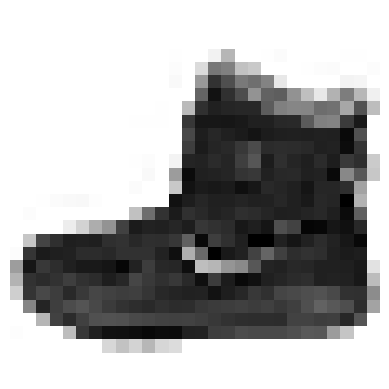

In [ ]:
some_image = X_train[0]
plot_fashion_image(some_image)
plt.show()


The corresponding label for this image is:

In [ ]:
y_train[0]


np.uint8(9)

To get a better sense of the variability in the dataset, we display several
training images.

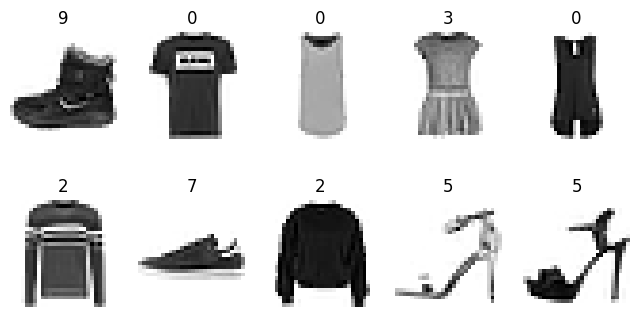

In [ ]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plot_fashion_image(X_train[i])
    plt.title(str(y_train[i]))

plt.show()


These examples illustrate that some classes are visually similar
(e.g., shirts, coats, and pullovers), which makes the classification task
non-trivial.


####  Flattening the Images

Machine learning classifiers in Scikit-Learn expect input data as
**1D feature vectors**.

Each 28 × 28 image is therefore reshaped into a vector of **784 features**.


In [ ]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

X_train_flat.shape, X_test_flat.shape


((60000, 784), (10000, 784))

Each image is represented by 784 features.

## Multiclass Classification

Binary classifiers distinguish between two classes.
Multiclass classifiers (also called multinomial classifiers) can distinguish
between more than two classes.

Fashion-MNIST is a **multiclass classification problem** with 10 classes
corresponding to different clothing items.


Some classifiers in Scikit-Learn can handle multiclass classification
**natively** (e.g., Logistic Regression, Random Forest).

Other classifiers are **binary classifiers by design** (e.g., SGDClassifier,
SVC), but Scikit-Learn automatically applies strategies such as:

- **One-vs-Rest (OvR)**  
- **One-vs-One (OvO)**

### Baseline model – Logistic Regression

In [ ]:
X_train_prep = X_train_flat / 255.0
# X_test  = X_test / 255.0

log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)
log_reg.fit(X_train_prep, y_train)

y_pred_lr = log_reg.predict(X_test_flat)
lr_acc = accuracy_score(y_test, y_pred_lr)
 print(f"Logistic Regression Accuracy: {lr_acc:.4f}") #Logistic Regression Accuracy: 0.7457

Logistic Regression Accuracy: 0.7485


#### Confusion matrix (baseline)

In [ ]:
y_train_pred_reg = cross_val_predict(
    log_reg,
    X_train_flat,#with X_train ValueError: Found array with dim 3, while dim <= 2 is required by LogisticRegression.
    y_train,
    cv=3,
    n_jobs=-1
)

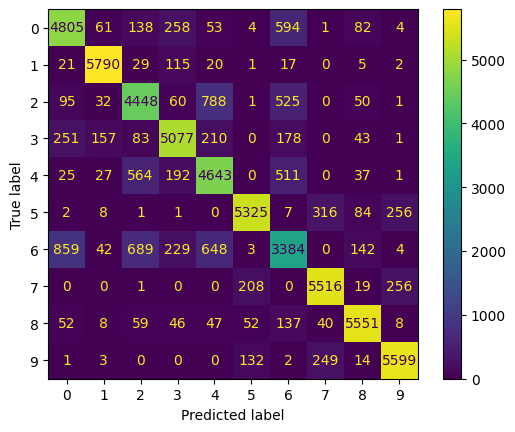

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred_reg
)
plt.show()

#### Data augmentation (optional)

This method will increase the raw data by data augmentation of images. We just added rotation, horizontal flip and fill mode.

**Source** [Fashion-MNIST-CNN](https://github.com/AkhilSinghRana/Fashion-MNIST-CNN/blob/master/code/util/dataLoader.py)

In [ ]:
class Datapreprocessing():

    def __init__(self,img_w,img_h, num_channels=1):
        self.img_w=img_w
        self.img_h=img_h
        self.num_channels=num_channels


        self.datagen = ImageDataGenerator(
            rotation_range=10,      # Randomly rotate images by up to 10 degrees
            width_shift_range=0.1,  # Randomly shift images horizontally by 10% of total width
            height_shift_range=0.1, # Randomly shift images vertically by 10% of total height
            zoom_range=0.1,         # Randomly zoom in/out by 10%

            # Optional: horizontal_flip is useful for clothes (a shirt is still a shirt when flipped)
            horizontal_flip=True,

            # fill_mode 'nearest' fills in new pixels created by rotation/width shifts
            # using the values of the closest existing pixels
            fill_mode='nearest'
        )



    def image_augmentation(self,image, nb_of_augmentation):
        '''
        Generates new images by augmentation
        image : raw image
        nb_augmentation: number of augmentations
        images: array with new images
        '''
        images = []
        image = image.reshape(1, self.img_h, self.img_w, self.num_channels)
        i = 0
        for b in self.datagen.flow(image, batch_size=1):
            images.append(b)
            i += 1
            if i >= nb_of_augmentation:
                # interrupt augmentation
                break
        return images

    def preprocess_data(self, images, targets, use_augmentation=False, nb_of_augmentation=1):
        """
        images: raw image
        targets: target label
        use_augmentation: True if augmentation should be used
        nb_of_augmentation: If use_augmentation=True, number of augmentations
        """
        print("Augmenting images...")
        X = []
        y = []
        for x_, y_ in zip(images, targets):

            # scaling pixels between 0.0-1.0
            x_ = x_ / 255.
            x_ = x_.reshape(self.img_h, self.img_w, self.num_channels)
            # data Augmentation
            if use_augmentation:
                argu_img = self.image_augmentation(x_, nb_of_augmentation)
                for a in argu_img:
                    reshaped_a = a.reshape(self.img_h, self.img_w, self.num_channels)
                    X.append(reshaped_a)
                    y.append(y_)


            X.append(x_)
            y.append(y_)
        print('*Preprocessing completed: %i samples\n' % len(X))
        return np.array(X), tf.keras.utils.to_categorical(y)






In [ ]:
_,img_w,img_h= X_train.shape
img_w
img_h


28

In [ ]:
_,img_w,img_h= X_train.shape
prep_img = Datapreprocessing(img_w,img_h)

# Perform data Augmentation
X_train_shaped, y_train_shaped = prep_img.preprocess_data(
                                        images=X_train,
                                        targets =y_train,
                                        use_augmentation=True,
                                        )
#X_test_shaped, y_test_shaped   = Datapreprocessing.preprocess_data(X_test,  y_test)

Augmenting images...
*Preprocessing completed: 120000 samples



In [ ]:
X_train_shaped.shape

(120000, 28, 28, 1)

Data augmentation introduces controlled variability in the training data, allowing the model to learn more robust features.

### Multiclass Classification with Support Vector Machines (OvO)

Support Vector Machines scale poorly with large datasets, so we train the
model only on a subset of the training data.


In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train_flat[:2000], y_train[:2000])

SVC(random_state=42)

We trained the classifier using the original labels (0–9).

Since there are more than two classes, Scikit-Learn automatically applies
the **One-vs-One (OvO)** strategy.

In [ ]:
some_image = X_train_flat[0]
svm_clf.predict([some_image])


array([9], dtype=uint8)

Internally, the classifier runs all OvO classifiers and selects the class
that wins the most pairwise comparisons.

In [ ]:
some_image_scores = svm_clf.decision_function([some_image])
some_image_scores.round(2)

array([[ 1.72, -0.3 ,  2.77,  0.72,  3.76,  7.25,  5.05,  8.26,  6.28,
         9.31]])

The predicted class is the one with the highest score.

In [ ]:
class_id = some_image_scores.argmax()
class_id

np.int64(9)

When a classifier is trained, it stores the list of class labels in the
`classes_` attribute.

In [ ]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
svm_clf.classes_[class_id]

np.uint8(9)

### Forcing OvR or OvO Manually

Scikit-Learn allows us to explicitly choose the multiclass strategy.

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train_flat[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [ ]:
ovr_clf.predict([some_image])

array([9], dtype=uint8)

In [ ]:
len(ovr_clf.estimators_)

10

### Multiclass Classification with SGDClassifier

SGDClassifier is a binary classifier, but Scikit-Learn automatically applies
the **One-vs-Rest** strategy for multiclass problems.

>SGD works like learning from experience **one example at a time**, instead of studying the entire book before making progress.
That is why it is **fast, memory-efficient, and scalable**, especially for very large or continuously growing datasets.

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train_flat, y_train)

SGDClassifier(random_state=42)

In [ ]:
sgd_clf.predict([some_image])

array([9], dtype=uint8)

The classifier may sometimes make incorrect predictions.
This is expected and highlights the importance of evaluation.

In [ ]:
sgd_clf.decision_function([some_image]).round()

array([[-62494., -66382., -26502., -56590., -49948., -27164., -15107.,
        -15514., -25594.,  13299.]])

The classifier assigns one score per class.
The class with the highest score is selected as the prediction.

### Evaluating the Multiclass Classifier

Since Fashion-MNIST classes are approximately balanced, accuracy is an
appropriate evaluation metric.

In [ ]:
cross_val_score(
    sgd_clf,
    X_train_flat,
    y_train,
    cv=3,
    scoring="accuracy"
)

array([0.78315, 0.81355, 0.82255])

We can improve the performance by scaling the input features.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat.astype("float64"))

sgd_clf = SGDClassifier(
    random_state=42,
    max_iter=3000,
    tol=1e-3
)

cross_val_score(
    sgd_clf,
    X_train_scaled,
    y_train,
    cv=3,
    scoring="accuracy"
)

array([0.8292 , 0.83475, 0.83635])

## Error Analysis

Once a reasonably good multiclass classifier has been trained, the next step
is to **analyze the types of errors it makes**.

The goal is not just to measure performance, but to understand *why* the
model fails and how it could be improved.


To analyze errors, we start by computing predictions on the training set
using cross-validation. This ensures that each prediction is made on data
the model has not seen during training.

In [ ]:
y_train_pred = cross_val_predict(
    sgd_clf,
    X_train_scaled,
    y_train,
    cv=3,
    n_jobs=-1
)

### Confusion Matrix (Raw Counts)

With 10 classes, the confusion matrix contains many values and can be hard
to read in numerical form.

A colored visualization makes it much easier to analyze.

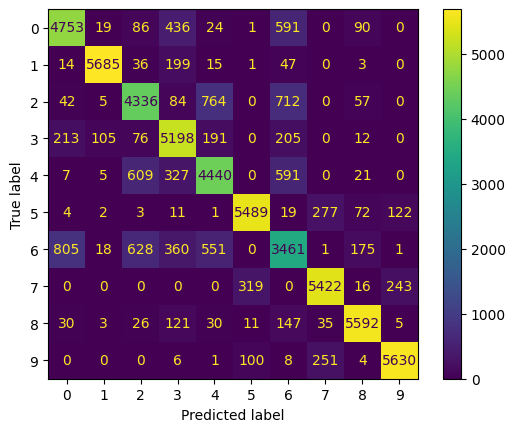

In [ ]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred
)
plt.show()

Most values lie on the main diagonal, which means that most images are
classified correctly.

However, darker cells may indicate either:
- more classification errors
- or fewer samples for that class

To distinguish between these effects, normalization is required.

### Normalized Confusion Matrix (by True Class)

We normalize each row by the total number of images in the corresponding
true class.

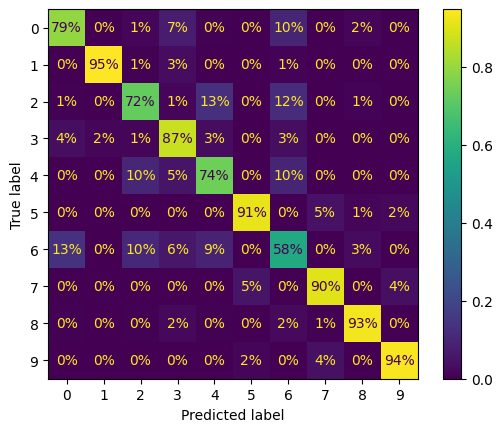

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    normalize="true",
    values_format=".0%"
)
plt.show()

This normalized confusion matrix shows the **classification accuracy per
class**.

We can now clearly see which classes are harder to classify and which
confusions are most frequent.

### Highlighting Errors Only

To focus exclusively on the errors, we assign zero weight to correct
predictions.

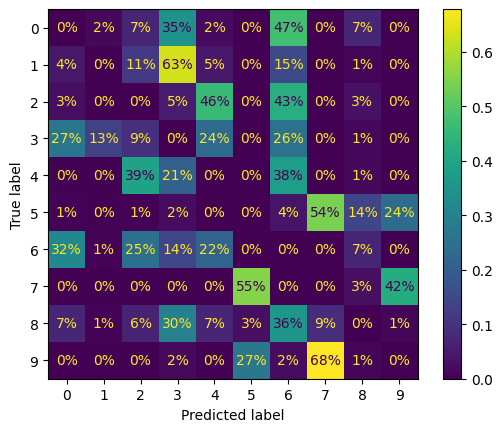

In [ ]:
sample_weight = (y_train_pred != y_train)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    sample_weight=sample_weight,
    normalize="true",
    values_format=".0%"
)
plt.show()

This visualization clearly shows which misclassifications are most common.

Be careful when interpreting percentages:
- The values now represent the **distribution of errors**, not overall error
  rates.

### Normalization by Predicted Class

We can also normalize the confusion matrix by column (predicted labels)
to see where false positives come from.

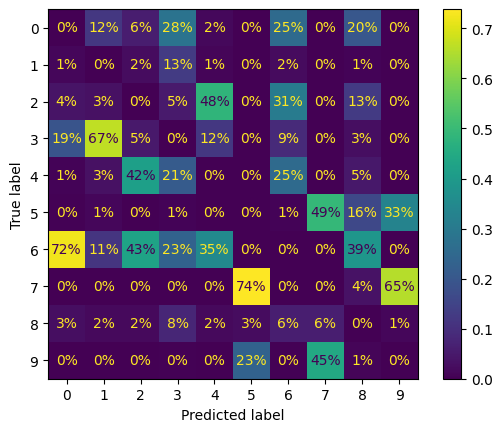

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    sample_weight=sample_weight,
    normalize="pred",
    values_format=".0%"
)
plt.show()

This representation helps us understand which true classes are most often
predicted as a given class.

Such insights can guide future improvements.

## Evaluate on the Test Set

In [ ]:
# y_test_pred_prob = sgd_clf.predict(X_test_flat)
# y_test_pred =np.argmax(y_test_pred_prob, axis=1)

y_test_pred = sgd_clf.predict(X_test_flat)

print(classification_report(
    y_test,
    y_test_pred,
    #target_names=fashion_classes
))

              precision    recall  f1-score   support

           0       0.86      0.67      0.75      1000
           1       0.94      0.96      0.95      1000
           2       0.80      0.49      0.61      1000
           3       0.82      0.83      0.83      1000
           4       0.71      0.70      0.71      1000
           5       0.98      0.82      0.89      1000
           6       0.47      0.69      0.56      1000
           7       0.90      0.93      0.92      1000
           8       0.84      0.96      0.90      1000
           9       0.89      0.96      0.92      1000

    accuracy                           0.80     10000
   macro avg       0.82      0.80      0.80     10000
weighted avg       0.82      0.80      0.80     10000

